In [14]:
import pandas as pd
import duckdb
import numpy as np
import seaborn as sns 
from scipy import stats
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.charts import compute_conversion_table

In [2]:
n26_funnel = pd.read_csv("../data/part_a_dataset.csv")

In [34]:
def perform_data_checks(df):
    
    null_counts = df.isnull().sum()
    if null_counts.sum() == 0:
        print("""
        No missing values found. """)
    else:
        print("""
        Missing values found:""")
        print(null_counts[null_counts > 0])

    
    if df.duplicated().sum() == 0:
        print("""
        No duplicate rows found. """)
    else:
        print("""
        Duplicate rows found. """)

    
    numeric_cols = df.select_dtypes(include=['number'])
    for col in numeric_cols:
        
        threshold = 2
        z_scores = (df[col] - df[col].mean()) / df[col].std()
        outliers = df[abs(z_scores) > threshold]
        if outliers.empty:
            print(f"""
            No outliers found in column '{col}'. """)
        else:
            print(f"""
            Outliers found in column '{col}': """)


def fix_date_column(df, date_col='date', drop_invalid=True, verbose=True):
    out = df.copy()
    raw = out[date_col].astype(str).str.strip()

    # format='mixed' infers per-element, covering both M/D/YY and ISO YYYY-M-D.
    # errors='coerce' -> NaT for anything impossible/unparseable.
    parsed = pd.to_datetime(raw, format='mixed', dayfirst=False, errors='coerce')

    bad_mask = parsed.isna()
    n_bad = int(bad_mask.sum())

    if verbose and n_bad:
        print(f"[fix_date_column] {n_bad} unparseable/impossible date(s) found:")
        print(raw[bad_mask].value_counts().to_string())

    out[date_col] = parsed

    if drop_invalid:
        out = out[~bad_mask].copy()
        if verbose:
            print(f"[fix_date_column] dropped {n_bad} row(s); "
                  f"{len(out)} of {len(df)} rows remain.")

    return out

def clean_data(): 
    
    df_dedups = duckdb.query(f"""
    select 
        date
        , country
        , marketing_channel
        , signups
        , kyc_init	
        , kyc_complete
        , card_activation	
        , first_transaction
    from (
        select *
            , ROW_NUMBER() over(PARTITION by date, country, marketing_channel) as rn 
        from n26_funnel 
    )
    where rn = 1       
""").to_df()
    
    df = fix_date_column(df_dedups, date_col='date', drop_invalid=True, verbose=True)
    return df

def zscore_outlier_scan(df, value_cols, volume_col='signups', sigma=3):
    """
    Flags z-score outliers (|z| > sigma) in each value column, checks each
    column's skewness (z-score assumes roughly normal data), and cross-references
    flagged rows against segment volume to separate real anomalies from
    small-sample noise.

    sigma : threshold in standard deviations. 3.0 is the standard outlier cutoff
            (~0.3% of a normal distribution); 2.0 is aggressive (~5% even when clean).

    Returns: (summary_df, flagged_df)
    """
    flags = pd.DataFrame(index=df.index)
    summary = []

    for c in value_cols:
        z = np.abs(stats.zscore(df[c]))
        is_out = z > sigma
        flags[c] = is_out
        summary.append({
            'column': c,
            'skewness': round(stats.skew(df[c]), 3),   # ~0 => symmetric, z-score valid
            'n_outliers': int(is_out.sum()),
            'pct_outliers': round(is_out.mean() * 100, 2),
        })

    out = df.copy()
    out['n_outlier_cols'] = flags.sum(axis=1)

    has_out = out['n_outlier_cols'] > 0
    print(f"Rows flagged in >=1 column (|z|>{sigma}): {has_out.sum()} / {len(out)} = % {round(has_out.sum() / len(out) * 100, 1)} ")
    print(f"  Flagged rows - median {volume_col}: {out.loc[has_out, volume_col].median():.0f}")
    print(f"  Clean rows   - median {volume_col}: {out.loc[~has_out, volume_col].median():.0f}")

    return pd.DataFrame(summary), out

def conversion_table(df, group_by):   
    g = df.groupby(group_by)[['signups', 'kyc_init', 'kyc_complete', 'card_activation', 'first_transaction']].sum()

    out = pd.DataFrame(index=g.index)
    out['su_kyci_cr']   = g.kyc_init          / g.signups           
    out['kyci_kycc_cr'] = g.kyc_complete      / g.kyc_init         
    out['kycc_card_cr'] = g.card_activation   / g.kyc_complete      
    out['card_ft_cr']   = g.first_transaction / g.card_activation  
    out['su_ft_cr']     = g.first_transaction / g.signups           

    out['su_kyci_dr'] = 1 - out['su_kyci_cr']
    out['kyci_kycc_dr'] = 1 - out['kyci_kycc_cr']
    out['kycc_card_dr'] = 1 - out['kycc_card_cr']
    out['card_ft_dr'] = 1 - out['card_ft_cr']
    out['su_ft_dr'] = 1 - out['su_ft_cr']

    out = out.join(g)  
 
    return out.reset_index()

def plot_kde(df, aggregation_level="month_year", rate_type = "conversion"):
    unique_aggregates = df[aggregation_level].unique()
    if aggregation_level == "month_year":
        rows, cols = 9, 4
    elif aggregation_level == "quarter_year":
        rows, cols = 4, 3
    elif aggregation_level == "year":
        rows, cols = 1, 3
    else:
        raise ValueError("Invalid aggregation level. Choose from 'month_year', 'quarter_year', or 'year'.")

    fig, axes = plt.subplots(rows, cols, figsize=(20, 20), constrained_layout=True)
    axes = axes.flatten()
    
    for i, aggregate in enumerate(unique_aggregates):
        subset = df[df[aggregation_level] == aggregate]
        ax = axes[i]
        if rate_type == "conversion":
            sns.kdeplot(data=subset, x="su_kyci_cr", label="su_kyci_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_cr", label="kyci_kycc_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_cr", label="kycc_card_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_cr", label="card_ft_cr", fill=True, ax=ax)
        else:
            sns.kdeplot(data=subset, x="su_kyci_dr", label="su_kyci_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_dr", label="kyci_kycc_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_dr", label="kycc_card_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_dr", label="card_ft_dr", fill=True, ax=ax)
        ax.set_title(f"{aggregate}")
        ax.set_xlabel("")
        ax.legend()

    for j in range(len(unique_aggregates), len(axes)):
        axes[j].axis("off")

    plt.show()

In [ ]:
def step_chi2(df, group_col, step_from, step_to, min_volume=0):
    """Tek adım chi-square. min_volume: step_from hacmi eşiğin altındaki gruplar elenir."""
    g = df.groupby(group_col)[[step_from, step_to]].sum()
    g = g[g[step_from] >= min_volume]                      # küçük segmentleri ele
    table = pd.DataFrame({'converted': g[step_to],
                          'not_converted': g[step_from] - g[step_to]})
    chi2, p, dof, _ = chi2_contingency(table)
    rates = g[step_to] / g[step_from] * 100
    return p, rates.max() - rates.min(), len(g)


def scan_chi2(df, dimensions, steps, min_volume=0):
    rows = []
    for dim_name, group_col in dimensions.items():
        for a, b in zip(steps[:-1], steps[1:]):
            p, spread, n = step_chi2(df, group_col, a, b, min_volume)
            rows.append({'dimension': dim_name, 'step': f'{a} -> {b}',
                         'n_groups': n, 'p_value': round(p, 4),
                         'significant_0.05': p < 0.05, 'rate_spread_pp': round(spread, 2)})
    return pd.DataFrame(rows)


def drill_step(df, group_col, step_from, step_to, n=10): 
    g = df.groupby(group_col)[[step_from, step_to]].sum()
    g['volume'] = g[step_from]
    g['conversion_%'] = (g[step_to] / g[step_from] * 100).round(1) 
    g = g.sort_values('conversion_%', ascending=False)
    cols = ['volume', 'conversion_%']
    return pd.concat([g[cols].head(n), g[cols].tail(n)])   # en yüksek + en düşük uçlar

def iqr_outlier_scan(df, value_cols, volume_col='signups', iqr_mult=1.5):
    """
    Flags IQR-based outliers in each value column and cross-references them
    with segment volume to distinguish real anomalies from small-sample noise.

    df          : conversion-rate table (one row per segment)
    value_cols  : list of rate columns to scan, e.g. ['su_kyci_cr', 'su_ft_cr', ...]
    volume_col  : volume column used to judge whether outliers are low-volume
    iqr_mult    : IQR multiplier for the fence (1.5 = standard)

    Returns: (summary_df, flagged_df)
      summary_df : per-column outlier counts and the normal range
      flagged_df : the original rows with an 'n_outlier_cols' column added
    """
    flags = pd.DataFrame(index=df.index)
    summary = []

    for c in value_cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - iqr_mult * iqr, q3 + iqr_mult * iqr
        is_out = (df[c] < low) | (df[c] > high)
        flags[c] = is_out
        summary.append({
            'column': c,
            'n_outliers': int(is_out.sum()),
            'normal_low': round(low, 4),
            'normal_high': round(high, 4),
            'min': round(df[c].min(), 4),
            'max': round(df[c].max(), 4),
        })

    out = df.copy()
    out['n_outlier_cols'] = flags.sum(axis=1)

    summary_df = pd.DataFrame(summary)
    flagged_df = out

    # volume comparison: are flagged rows systematically lower-volume?
    has_out = out['n_outlier_cols'] > 0
    print(f"Rows flagged in >=1 column: {has_out.sum()} / {len(out)}")
    print(f"  Flagged rows  - median {volume_col}: {out.loc[has_out, volume_col].median():.0f}")
    print(f"  Clean rows    - median {volume_col}: {out.loc[~has_out, volume_col].median():.0f}")

    return summary_df, flagged_df

In [4]:
df = clean_data()

df["month_year"] = df["date"].dt.to_period("M")
df["quarter_year"] = df["date"].dt.to_period("Q")
df["week_year"] = df["date"].dt.to_period("W")
df["year"] = df["date"].dt.to_period("Y")

perform_data_checks(df)


[fix_date_column] 70 unparseable/impossible date(s) found:
date
2019-2-29    14
2017-2-29    13
2018-2-29    13
2019-2-30    11
2017-2-30    10
2018-2-30     9
[fix_date_column] dropped 70 row(s); 12094 of 12164 rows remain.

        No missing values found. 

        No duplicate rows found. 

            No outliers found in column 'signups'. 

            No outliers found in column 'kyc_init'. 

            No outliers found in column 'kyc_complete'. 

            No outliers found in column 'card_activation'. 

            No outliers found in column 'first_transaction'. 


In [5]:
df[["signups","kyc_init","kyc_complete","card_activation","first_transaction"]].describe()

,signups,kyc_init,kyc_complete,card_activation,first_transaction
count,12094.000000,12094.000000,12094.000000,12094.000000,12094.000000
mean,95.020506,75.009426,54.950141,45.055234,34.960972
std,3.173853,3.179398,3.169969,3.173673,3.160232
min,90.000000,70.000000,50.000000,40.000000,30.000000
25%,92.000000,72.000000,52.000000,42.000000,32.000000
50%,95.000000,75.000000,55.000000,45.000000,35.000000
75%,98.000000,78.000000,58.000000,48.000000,38.000000
max,100.000000,80.000000,60.000000,50.000000,40.000000


In [35]:
ct_monthly = conversion_table(df, group_by=["month_year", "marketing_channel", "country"])
ct_quarterly = conversion_table(df, group_by=["quarter_year", "marketing_channel", "country"])

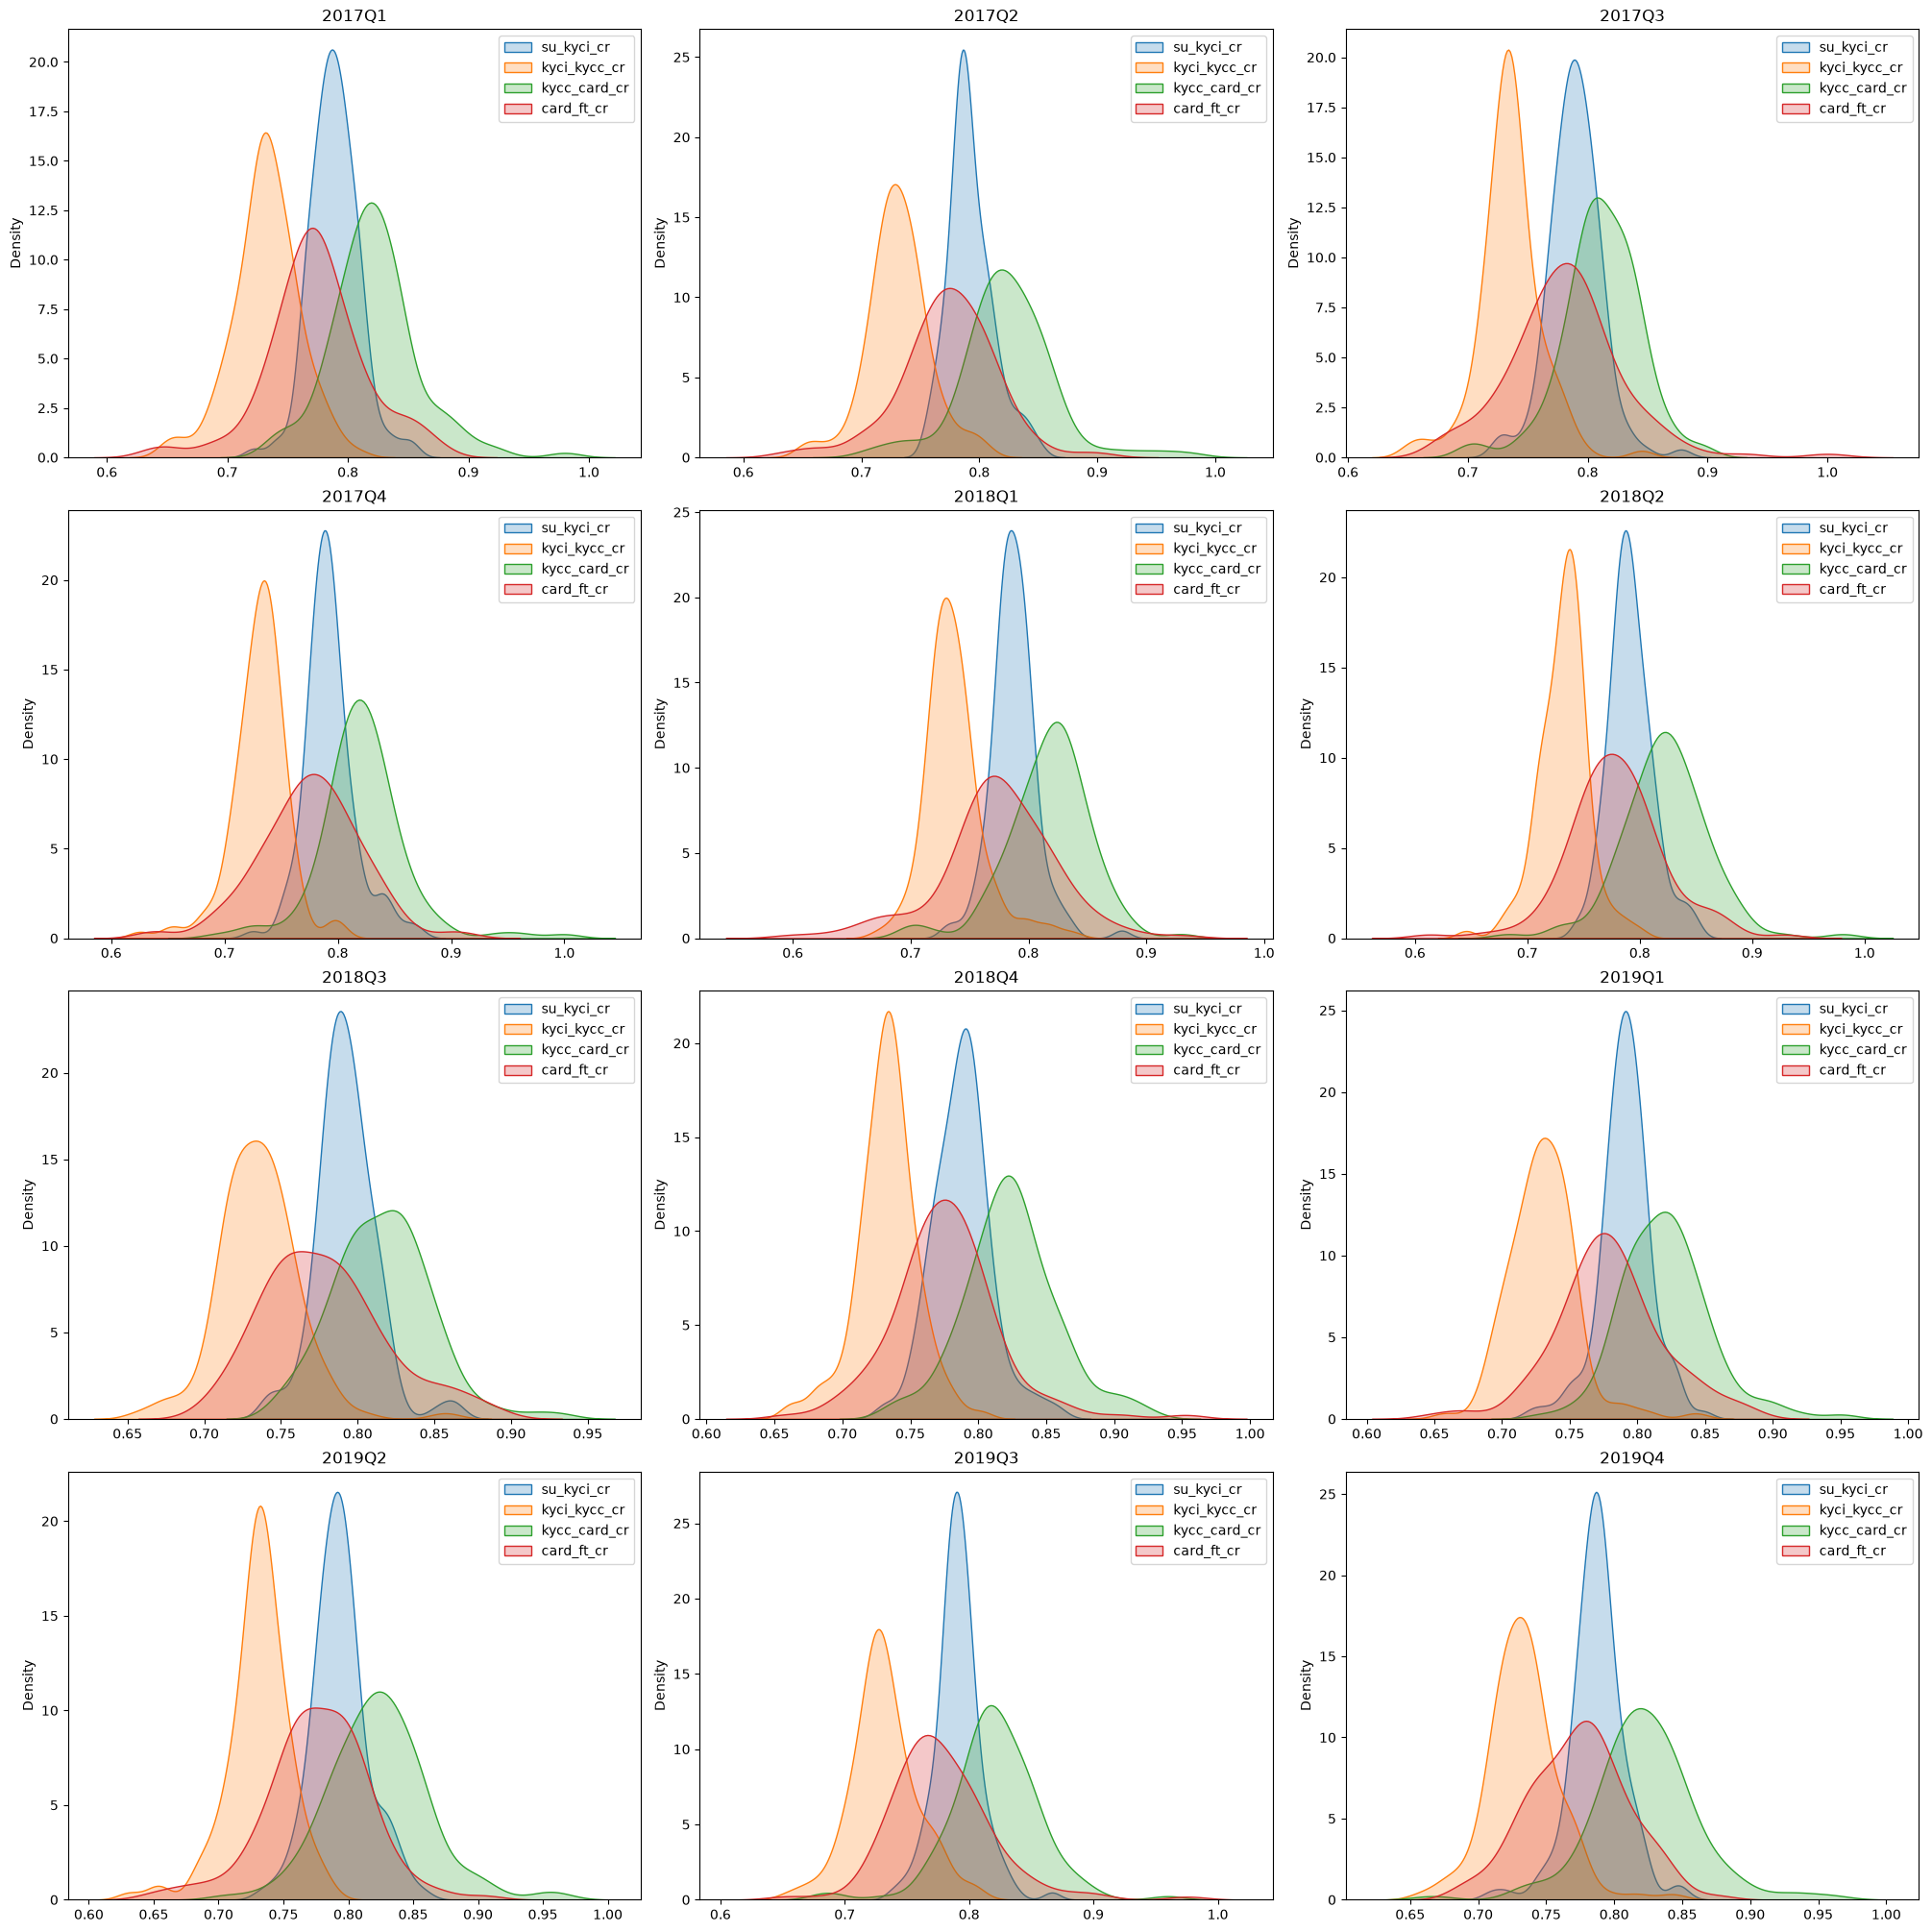

In [36]:
plot_kde(ct_quarterly, aggregation_level="quarter_year")

In [37]:
ct_quarterly

,quarter_year,marketing_channel,country,su_kyci_cr,kyci_kycc_cr,kycc_card_cr,card_ft_cr,su_ft_cr,su_kyci_dr,kyci_kycc_dr,kycc_card_dr,card_ft_dr,su_ft_dr,signups,kyc_init,kyc_complete,card_activation,first_transaction
0,2017Q1,affiliate,BEL,0.777944,0.735776,0.785059,0.814691,0.366092,0.222056,0.264224,0.214941,0.185309,0.633908,1333,1037,763,599,488
1,2017Q1,affiliate,DEU,0.787215,0.748610,0.808321,0.770221,0.366900,0.212785,0.251390,0.191679,0.229779,0.633100,1142,899,673,544,419
2,2017Q1,affiliate,ESP,0.795309,0.727882,0.826888,0.797327,0.381663,0.204691,0.272118,0.173112,0.202673,0.618337,938,746,543,449,358
3,2017Q1,affiliate,EST,0.808511,0.697368,0.811321,0.802326,0.367021,0.191489,0.302632,0.188679,0.197674,0.632979,188,152,106,86,69
4,2017Q1,affiliate,FRA,0.784964,0.733265,0.817416,0.768041,0.361358,0.215036,0.266735,0.182584,0.231959,0.638642,1237,971,712,582,447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,2019Q4,partnership,IRL,0.789030,0.729947,0.802198,0.744292,0.343882,0.210970,0.270053,0.197802,0.255708,0.656118,474,374,273,219,163
1467,2019Q4,partnership,ITA,0.819495,0.713656,0.839506,0.823529,0.404332,0.180505,0.286344,0.160494,0.176471,0.595668,277,227,162,136,112
1468,2019Q4,partnership,NOR,0.776042,0.758389,0.743363,0.833333,0.364583,0.223958,0.241611,0.256637,0.166667,0.635417,192,149,113,84,70
1469,2019Q4,partnership,POL,0.772632,0.757493,0.820144,0.741228,0.355789,0.227368,0.242507,0.179856,0.258772,0.644211,475,367,278,228,169


In [38]:
q_summary, q_outlier = zscore_outlier_scan(df = ct_quarterly,
                                           value_cols = ['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr'],
                                           sigma=2.5)

Rows flagged in >=1 column (|z|>2.5): 142 / 1471 = % 9.7 
  Flagged rows - median signups: 100
  Clean rows   - median signups: 862


In [44]:
ct_monthly[['su_kyci_dr','kyci_kycc_dr', 'kycc_card_dr', 'card_ft_dr']].describe()

,su_kyci_dr,kyci_kycc_dr,kycc_card_dr,card_ft_dr
count,3835.000000,3835.000000,3835.000000,3835.000000
mean,0.210225,0.266608,0.178990,0.222662
std,0.028701,0.035833,0.050909,0.062090
min,0.111111,0.142857,0.000000,0.000000
25%,0.193548,0.246575,0.149533,0.186047
50%,0.210667,0.267327,0.180212,0.223827
75%,0.227535,0.288108,0.211194,0.260725
max,0.300000,0.375000,0.333333,0.400000


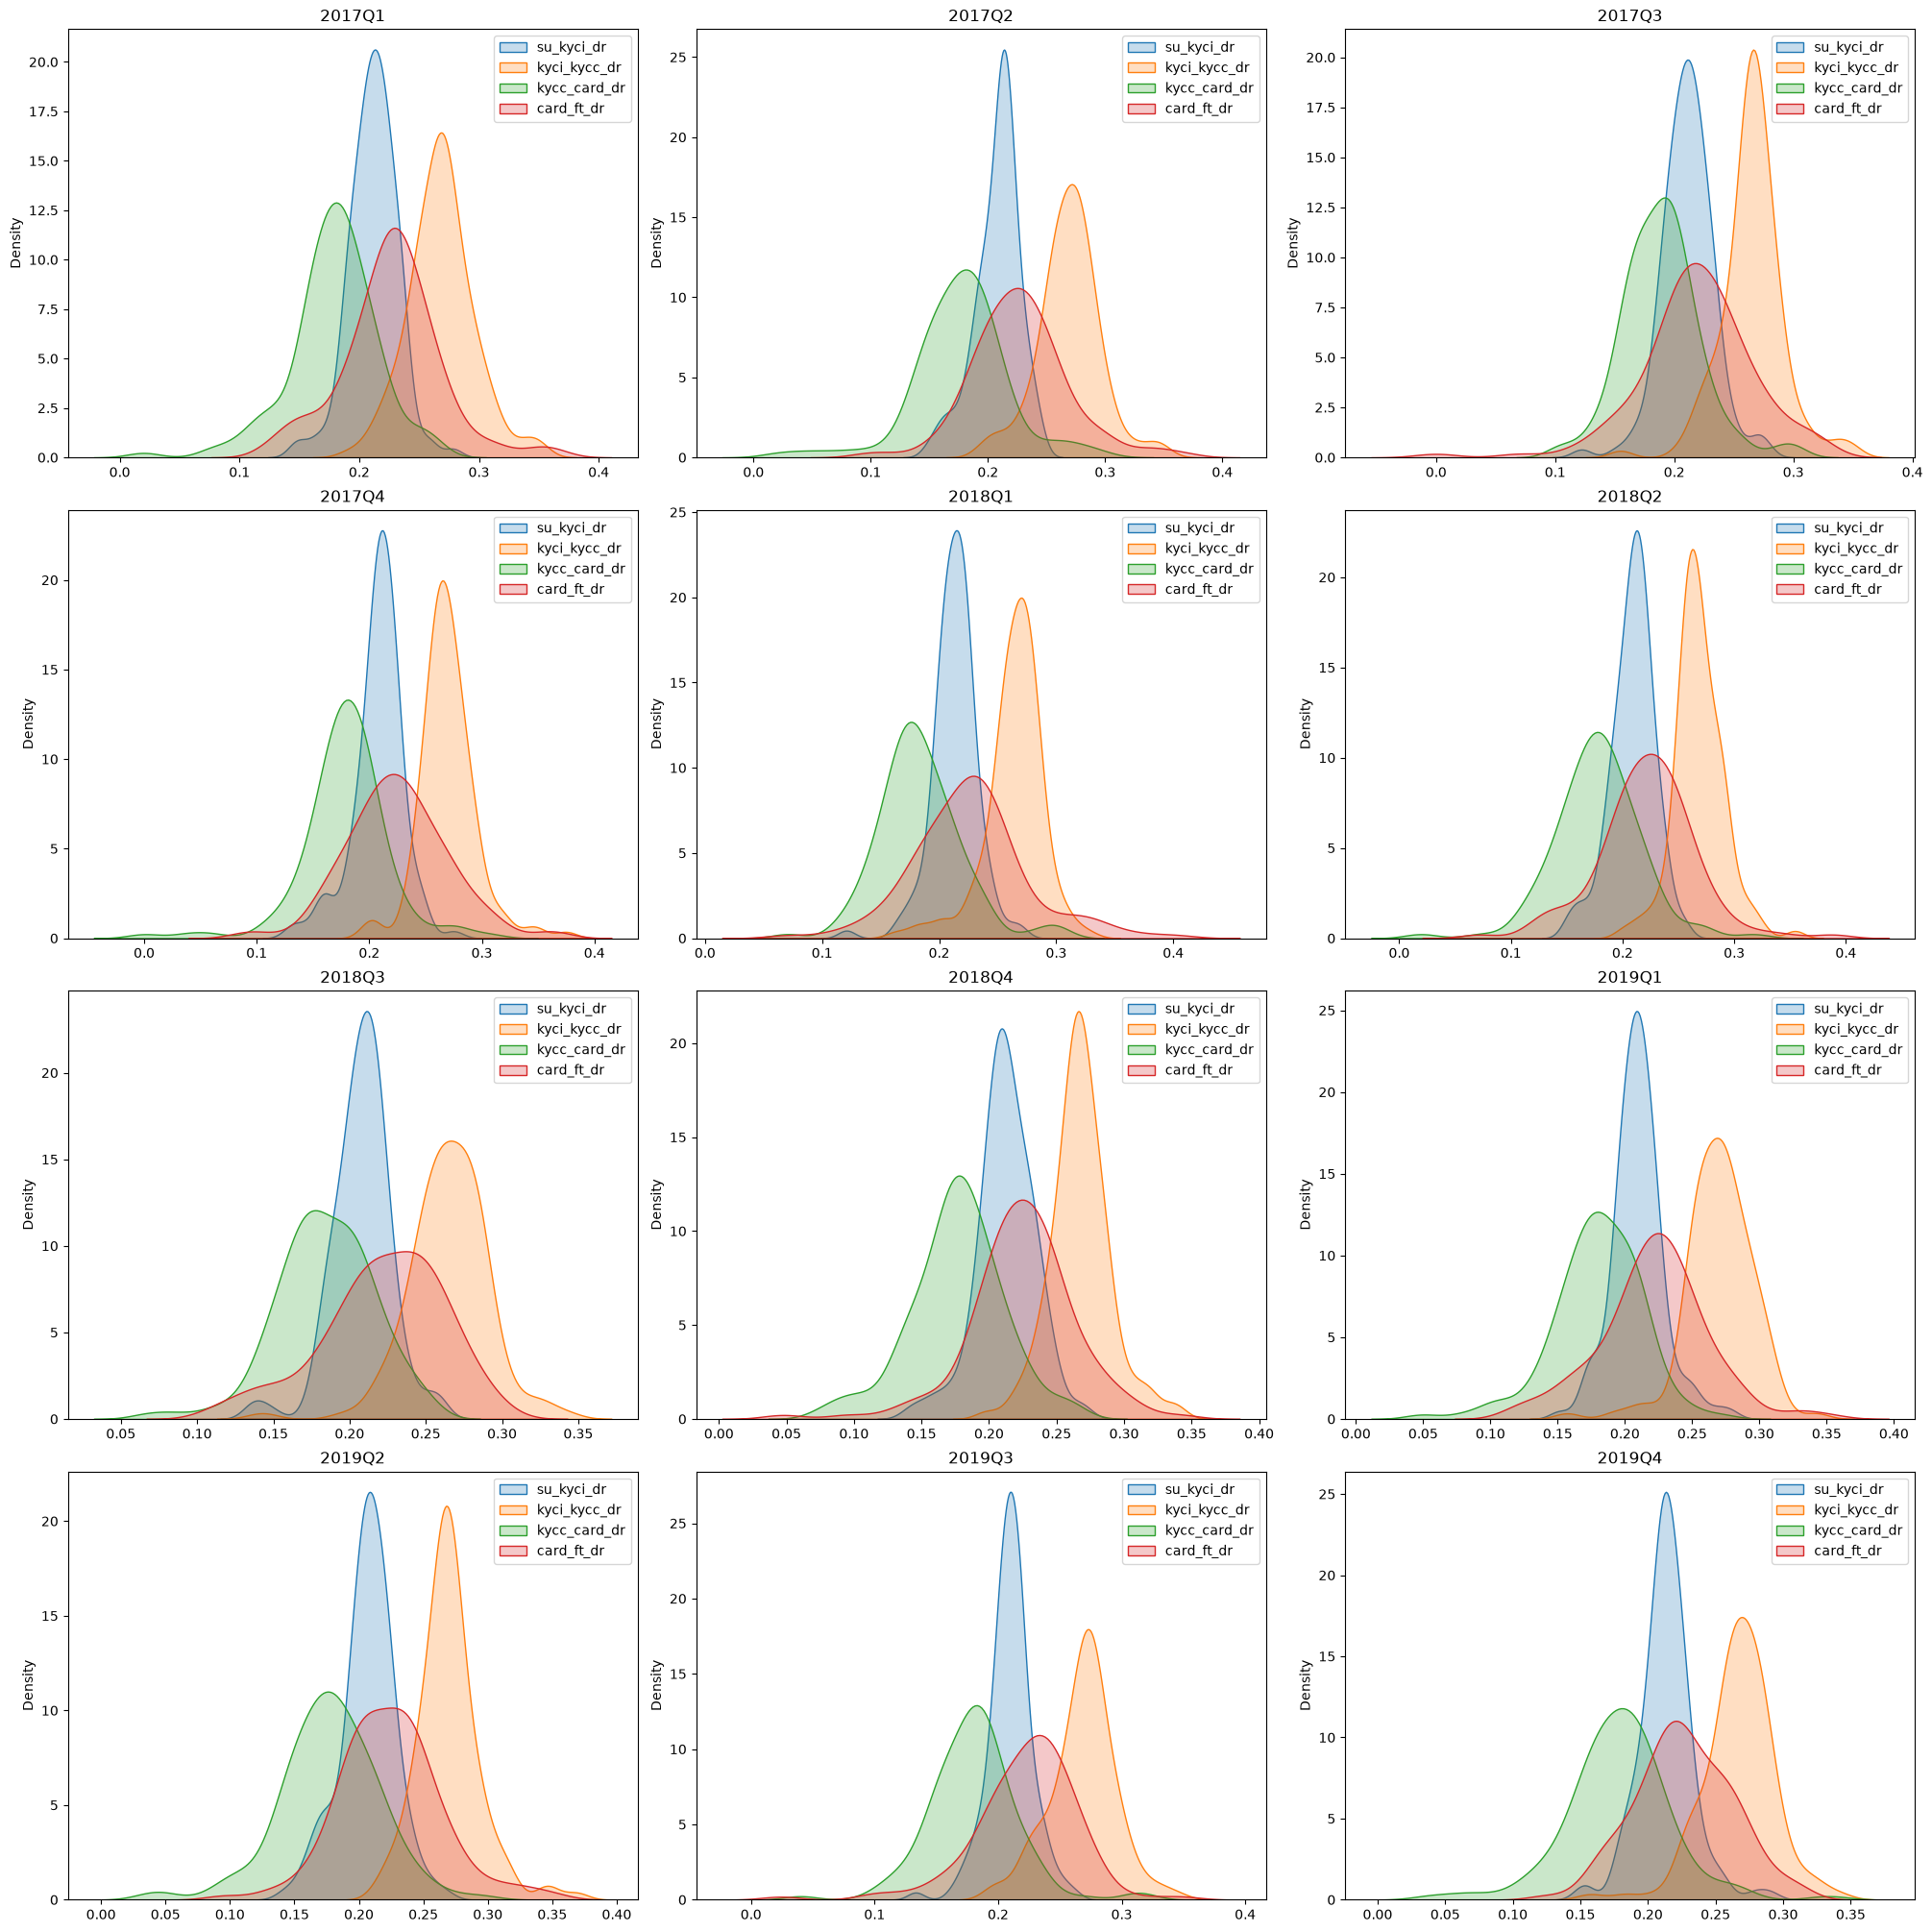

In [ ]:
plot_kde(ct_quarterly.drop(['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr', 'signups','kyc_init', 'kyc_complete', 'card_activation', 'first_transaction'], axis=1), 
         aggregation_level="quarter_year", 
         rate_type = "drop")


In [61]:
df_mc = df.groupby("marketing_channel")[["signups", "first_transaction"]].sum().sort_values("signups", ascending=False).reset_index()
df_mc["su_ft_cr"] = df_mc["first_transaction"] / df_mc["signups"]
df_mc.sort_values("su_ft_cr", ascending=False, inplace=True)
df_mc

,marketing_channel,signups,first_transaction,su_ft_cr
9,partnership,38379,14233,0.370854
1,organic search,135993,50275,0.369688
3,paid search,132589,48921,0.368967
5,app store,122273,45061,0.368528
7,affiliate,116453,42911,0.368483
4,direct,131488,48433,0.368345
2,friend referral,134139,49247,0.367134
0,other organic,136654,50102,0.366634
8,display,60844,22300,0.366511
6,paid social,116623,42699,0.366128


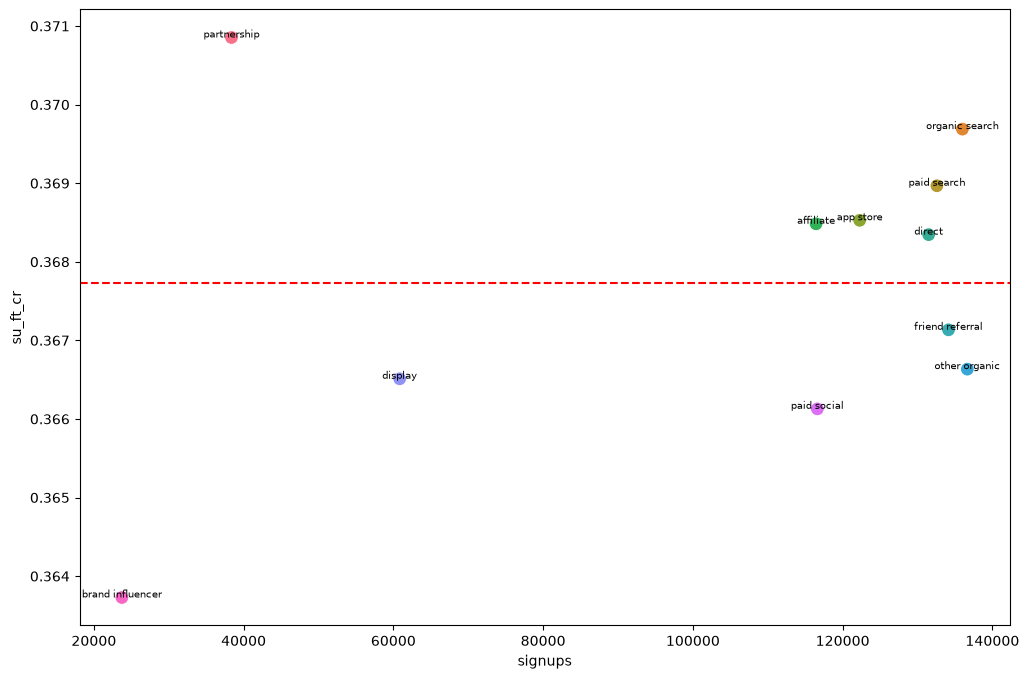

In [69]:
avg_su_ft_cr = df_mc["su_ft_cr"].mean()

plt.figure(figsize=(12, 8))  # Adjust the figure size
sns.scatterplot(data=df_mc, x="signups", y="su_ft_cr", hue="marketing_channel", s=100, legend=False)
for i in range(len(df_mc)):
    plt.text(df_mc["signups"][i], df_mc["su_ft_cr"][i], df_mc["marketing_channel"][i], fontsize=7, ha='center')
plt.axhline(avg_su_ft_cr, color="red", linestyle="--", label=f"Avg su_ft_cr: {avg_su_ft_cr:.2f}")
plt.show()